<a href="https://colab.research.google.com/github/Spring-anne/Proyecto-Tecnolochicas-Python/blob/exploracion/ProyectoFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***.𖥔 ݁ ˖ 🎮Analisis de tendencias de Videojuegos desde 1980-2025🎮.𖥔 ݁ ˖***
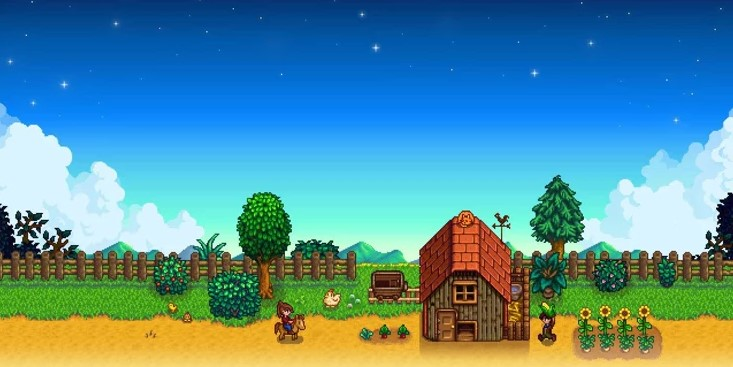

Este proyecto tiene como fin analizar las tendencias de videojuegos populares desde 1980 hasta 2025, con el propósito de identificar cómo ha ido evolucionado la industria a lo largo de estas cuatro décadas.

El problema de investigación se centra en comprender cuáles han sido los factores que han influido en la popularidad de los videojuegos a lo largo del tiempo, tales como los géneros predominantes, las plataformas más utilizadas, las compañías desarrolladoras y distribuidoras, así como la recepción de los usuarios y la crítica especializada.

Para este proyecto se implemento un conjunto de datos en formato .csv, extraido de kaggle contando con 60000 filas y 14 columnas con datos relevantes a la pregunta de investigación.

# ***.𖥔 ݁ ˖ 🎮Imports iniciales🎮.𖥔 ݁ ˖***


Importamos las liberias que ocuparemos durante el desarrollo del proyecto

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
from functools import reduce

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# ***.𖥔 ݁ ˖ 🎮Exploracion inicial de los datos🎮.𖥔 ݁ ˖***
Divagamos un poco en el conjunto de datos cargado usando funciones utiles de pandas como .head(), .tail() y .sample().

Igual describimos la informacion del conjunto para saber de que tipo de dato es cada columna, si existen valores nulos, y las estadisticas de algunos campos utiles (rating, release_date y title).



In [6]:
#Funcion para cargar el archivo csv
def cargar_datos(ruta_csv: str):
    try:
        df = pd.read_csv(ruta_csv)
        print(f"Archivo cargado correctamente: {df.shape[0]} filas, {df.shape[1]} columnas.")
        return df
    except FileNotFoundError:
        raise FileNotFoundError(f"No se encontro el archivo: {ruta_csv}")

#Cargamos el csv y mostramos las primeras 5 filas del conjunto
df_crudo = cargar_datos("backloggd_games.csv")
df_crudo.head(5)

Archivo cargado correctamente: 60000 filas, 14 columnas.


,Unnamed: 0,Title,Release_Date,Developers,Summary,Platforms,Genres,Rating,Plays,Playing,Backlogs,Wishlist,Lists,Reviews
0,0,Elden Ring,"Feb 25, 2022","['FromSoftware', 'Bandai Namco Entertainment']","Elden Ring is a fantasy, action and open world...","['Windows PC', 'PlayStation 4', 'Xbox One', 'P...","['Adventure', 'RPG']",4.5,21K,4.1K,5.6K,5.5K,4.6K,3K
1,1,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",The Legend of Zelda: Breath of the Wild is the...,"['Wii U', 'Nintendo Switch']","['Adventure', 'Puzzle']",4.4,35K,3.1K,5.6K,3K,5.1K,3K
2,2,Hades,"Dec 07, 2018",['Supergiant Games'],A rogue-lite hack and slash dungeon crawler in...,"['Windows PC', 'Mac', 'PlayStation 4', 'Xbox O...","['Adventure', 'Brawler', 'Indie', 'RPG']",4.3,25K,3.5K,7.3K,4K,3.2K,2.1K
3,3,Hollow Knight,"Feb 24, 2017",['Team Cherry'],A 2D metroidvania with an emphasis on close co...,"['Windows PC', 'Mac', 'Linux', 'Nintendo Switch']","['Adventure', 'Indie', 'Platform']",4.4,25K,2.7K,9.6K,2.6K,3.4K,2.1K
4,4,Undertale,"Sep 15, 2015","['tobyfox', '8-4']","A small child falls into the Underground, wher...","['Windows PC', 'Mac', 'Linux', 'PlayStation 4'...","['Adventure', 'Indie', 'RPG', 'Turn Based Stra...",4.2,32K,728,5.7K,2.1K,3.9K,2.5K


In [7]:
#Mostramos la cola del conjunto de datos, los ultimos 5 datos
df_crudo.tail(5)

,Unnamed: 0,Title,Release_Date,Developers,Summary,Platforms,Genres,Rating,Plays,Playing,Backlogs,Wishlist,Lists,Reviews
59995,59995,Dragon Spirits,"Apr 25, 2023","['FHNBHJ', 'indienova']",While constantly working on a video game witho...,['Windows PC'],['RPG'],NaN,2,0,1,5,3,0
59996,59996,Pathfinder: Kingmaker - Definitive Edition,"Aug 18, 2020","['Owlcat Games', 'Deep Silver']",The Definitive Edition will have all of the DL...,"['PlayStation 4', 'Xbox One']","['RPG', 'Tactical']",3.7,9,0,19,1,7,1
59997,59997,Sainth,"Apr 11, 2008",['Neo Kuriyo'],"Years after the events of ""Wraith"", a young gi...",['Windows PC'],[],NaN,1,0,0,2,0,0
59998,59998,Dragon Spirits,"Apr 25, 2023","['FHNBHJ', 'indienova']",While constantly working on a video game witho...,['Windows PC'],['RPG'],NaN,2,0,1,5,3,0
59999,59999,Pathfinder: Kingmaker - Definitive Edition,"Aug 18, 2020","['Owlcat Games', 'Deep Silver']",The Definitive Edition will have all of the DL...,"['PlayStation 4', 'Xbox One']","['RPG', 'Tactical']",3.7,9,0,19,1,7,1


In [ ]:
#Elegimos 10 filas aleatorias
df_crudo.sample(10)

,Unnamed: 0,Title,Release_Date,Developers,Summary,Platforms,Genres,Rating,Plays,Playing,Backlogs,Wishlist,Lists,Reviews
11597,11597,JB: The Super Bass,"Dec 15, 1995","['Gaps', 'Naxat Soft']",For some reason the Japanese love bass fishing...,['Super Famicom'],['Sport'],NaN,1,0,0,0,0,0
23516,23516,Lune,"Jun 20, 2016",[],"Lune is a experiential haiku, a short poem ded...",['Windows PC'],"['Indie', 'Simulator']",NaN,0,0,0,0,1,0
20855,20855,Dezaemon Plus,"May 24, 1996",['Athena'],A vertical shooter that lets you create your o...,['PlayStation'],['Shooter'],NaN,2,1,2,3,4,0
2231,2231,Rock Band 3,"Oct 26, 2010","['MTV Games', 'Harmonix Music Systems']",Rock Band 3 adds 83 new songs to the Rock Band...,"['Xbox 360', 'PlayStation 3', 'Wii']",['Music'],4.0,1.2K,5,46,40,131,37
55544,55544,ReCaptcha V4,"Dec 31, 2021",['Performave'],A parody ReCaptcha in which you play chess aga...,['Web browser'],['Card & Board Game'],NaN,2,0,0,0,0,0
50357,50357,Q*bert,"Dec 31, 1983",['Parker Brothers'],NaN,['Handheld Electronic LCD'],[],NaN,1,0,0,0,0,1
2974,2974,J-Stars Victory Vs+,"Jun 24, 2015","['Spike ChunSoft', 'Bandai Namco Entertainment']",Your favorite Shonen Jump heroes jump off the ...,"['PlayStation 4', 'PlayStation 3', 'PlayStatio...","['Brawler', 'Fighting']",2.6,773,4,70,33,68,37
48196,48196,Powerpuff Girls: Zom-B-Gone!,"Oct 11, 2007",[],"Shoot magic elements, watch out for magic bags...",['Web browser'],"['Arcade', 'Point-and-Click']",1.9,12,0,0,0,2,0
6738,6738,Edge,"Dec 01, 2008","['Mobigame', 'Two Tribes B.V.']",In Edge players take direct control of the cub...,"['Windows PC', 'Android', 'Mac', 'Wii U', 'Lin...","['Adventure', 'Indie', 'Platform', 'Puzzle']",3.2,320,3,65,13,48,16
8195,8195,Hentai Nazi,"Jan 07, 2020",['AmagSwag Games'],"Hentai Nazi - It’s not just for you, it smells...",['Windows PC'],['Shooter'],2.3,75,0,4,4,6,13


In [8]:
#Imprimimos la informacion del df crudo
print(df_crudo.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    60000 non-null  int64  
 1   Title         60000 non-null  object 
 2   Release_Date  60000 non-null  object 
 3   Developers    60000 non-null  object 
 4   Summary       55046 non-null  object 
 5   Platforms     60000 non-null  object 
 6   Genres        60000 non-null  object 
 7   Rating        25405 non-null  float64
 8   Plays         60000 non-null  object 
 9   Playing       60000 non-null  object 
 10  Backlogs      60000 non-null  object 
 11  Wishlist      60000 non-null  object 
 12  Lists         60000 non-null  object 
 13  Reviews       60000 non-null  object 
dtypes: float64(1), int64(1), object(12)
memory usage: 6.4+ MB
None


In [9]:
#Exploracion de datos nulos, repetidos
print("--VALORES NULOS--")
print(df_crudo.isnull().sum())
print()
print("--FILAS DUPLICADOS--")
print(df_crudo.duplicated().sum())
print()
print("--TITULOS DUPLICADOS(REMASTERS/RERELEASES/MULTI-PLATAFORMA)--")
print(df_crudo.duplicated(subset=['Title']).sum())

--VALORES NULOS--
Unnamed: 0          0
Title               0
Release_Date        0
Developers          0
Summary          4954
Platforms           0
Genres              0
Rating          34595
Plays               0
Playing             0
Backlogs            0
Wishlist            0
Lists               0
Reviews             0
dtype: int64

--FILAS DUPLICADOS--
0

--TITULOS DUPLICADOS(REMASTERS/RERELEASES/MULTI-PLATAFORMA)--
19015


In [10]:
#Consulta de estadisticas
print("--ESTADISTICAS(RATING)")
print(df_crudo['Rating'].describe())
print("\n")
print("--ESTADISTICAS(RELEASE DATE)")
print(df_crudo['Release_Date'].describe())

--ESTADISTICAS(RATING)
count    25405.000000
mean         3.033171
std          0.735573
min          0.300000
25%          2.600000
50%          3.100000
75%          3.500000
max          5.000000
Name: Rating, dtype: float64


--ESTADISTICAS(RELEASE DATE)
count     60000
unique     8956
top         TBD
freq       8019
Name: Release_Date, dtype: object


#***.𖥔 ݁ ˖ 🎮Limpieza de datos🎮.𖥔 ݁ ˖ ***
Identificamos los valores faltantes, eliminamos duplicados y preparamos los datos para el analisis.
Investigando el conjunto de datos identifique varios valores nulos en las descripciones de los videojuegos(summary)

En la seccion de calificacion(Rating) me encontre con que solo 25405 filas cuentan con una calificacion, lo que puede llegar a afectar o sesgar el analisis pero decidi continuar con este conjunto de datos por el resto de las columnas con informacion util.

In [11]:
#Funcion para pasar Strings con formato de lista
def recorrer_lista(valor):
  if pd.isna(valor):
    return []
  try:
      resultado = ast.literal_eval(valor)
      if isinstance(resultado, list):
          return [str(x).strip() for x in resultado if str(x).strip()]
      return []
  except (ValueError, SyntaxError):
      return []

#Funcion para convertir las cadenas de 21k a valores numericos
def conversion_numerica(valor):
    if pd.isna(valor):
        return np.nan

    valor = str(valor).strip()

    if valor == "" or valor.lower() == "nan":
        return np.nan
    if valor.endswith("K"):
        return float(valor[:-1]) * 1000
    if valor.endswith("M"):
        return float(valor[:-1]) * 1000000
    return float(valor)

#Funcion para tratar los valores faltantes, eliminar duplicados, y darle formato
def limpieza_datos(df: pd.DataFrame):
  df = df.copy()

  df = df.drop_duplicates()
  if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

  df["Release_Date"]= df["Release_Date"].replace("TBD", np.nan)
  df["Release_Date"]= pd.to_datetime(df["Release_Date"], format='%b %d, %Y', errors='coerce')
  df['Year']= df["Release_Date"].dt.year

  df = df[(df["Year"].isna()) | ((df["Year"] >= 1980) & (df["Year"] <= 2025))]

  df["Summary"] = df["Summary"].fillna("No hay descripcion disponible")

   # --- Columnas de listas (Developers / Genres / Platforms) ---
  df["Developers_list"] = df["Developers"].apply(recorrer_lista)
  df["Genres_list"] = df["Genres"].apply(recorrer_lista)
  df["Platforms_list"] = df["Platforms"].apply(recorrer_lista)

  # --- Columnas numéricas de popularidad (usa map, ver sección de funciones) ---
  columnas_popularidad = ["Plays", "Playing", "Backlogs", "Wishlist", "Lists", "Reviews"]
  for col in columnas_popularidad:
      df[f"{col}_num"] = list(map(conversion_numerica, df[col]))

  #Rating mantenemos el NaN aunque solo 25405 filas tienen rating(Esto)
  df["Rating"] = pd.to_numeric(df["Rating"], errors="coerce")

  # Eliminar filas sin ningun dato relevante (sin developer y sin genero)
  df = df[~((df["Developers_list"].apply(len) == 0) & (df["Genres_list"].apply(len) == 0))]

  print(f"Limpieza finalizada. Dataset resultante: {df.shape[0]} filas, {df.shape[1]} columnas.")
  return df

df_limpio = limpieza_datos(df_crudo)
df_limpio.head(4)


Limpieza finalizada. Dataset resultante: 55193 filas, 23 columnas.


,Title,Release_Date,Developers,Summary,Platforms,Genres,Rating,Plays,Playing,Backlogs,Wishlist,Lists,Reviews,Year,Developers_list,Genres_list,Platforms_list,Plays_num,Playing_num,Backlogs_num,Wishlist_num,Lists_num,Reviews_num
0,Elden Ring,2022-02-25,"['FromSoftware', 'Bandai Namco Entertainment']","Elden Ring is a fantasy, action and open world...","['Windows PC', 'PlayStation 4', 'Xbox One', 'P...","['Adventure', 'RPG']",4.5,21K,4.1K,5.6K,5.5K,4.6K,3K,2022.0,"[FromSoftware, Bandai Namco Entertainment]","[Adventure, RPG]","[Windows PC, PlayStation 4, Xbox One, PlayStat...",21000.0,4100.0,5600.0,5500.0,4600.0,3000.0
1,The Legend of Zelda: Breath of the Wild,2017-03-03,"['Nintendo', 'Nintendo EPD Production Group No...",The Legend of Zelda: Breath of the Wild is the...,"['Wii U', 'Nintendo Switch']","['Adventure', 'Puzzle']",4.4,35K,3.1K,5.6K,3K,5.1K,3K,2017.0,"[Nintendo, Nintendo EPD Production Group No. 3]","[Adventure, Puzzle]","[Wii U, Nintendo Switch]",35000.0,3100.0,5600.0,3000.0,5100.0,3000.0
2,Hades,2018-12-07,['Supergiant Games'],A rogue-lite hack and slash dungeon crawler in...,"['Windows PC', 'Mac', 'PlayStation 4', 'Xbox O...","['Adventure', 'Brawler', 'Indie', 'RPG']",4.3,25K,3.5K,7.3K,4K,3.2K,2.1K,2018.0,[Supergiant Games],"[Adventure, Brawler, Indie, RPG]","[Windows PC, Mac, PlayStation 4, Xbox One, Pla...",25000.0,3500.0,7300.0,4000.0,3200.0,2100.0
3,Hollow Knight,2017-02-24,['Team Cherry'],A 2D metroidvania with an emphasis on close co...,"['Windows PC', 'Mac', 'Linux', 'Nintendo Switch']","['Adventure', 'Indie', 'Platform']",4.4,25K,2.7K,9.6K,2.6K,3.4K,2.1K,2017.0,[Team Cherry],"[Adventure, Indie, Platform]","[Windows PC, Mac, Linux, Nintendo Switch]",25000.0,2700.0,9600.0,2600.0,3400.0,2100.0


In [14]:
df_limpio.sample(5)

,Title,Release_Date,Developers,Summary,Platforms,Genres,Rating,Plays,Playing,Backlogs,Wishlist,Lists,Reviews,Year,Developers_list,Genres_list,Platforms_list,Plays_num,Playing_num,Backlogs_num,Wishlist_num,Lists_num,Reviews_num
14881,Imagine Lifetimes,2020-09-25,['Frycandle'],A satirical simulation game about the meaning ...,['Windows PC'],"['Indie', 'Simulator']",2.2,7,0,1,1,1,1,2020.0,[Frycandle],"[Indie, Simulator]",[Windows PC],7.0,0.0,1.0,1.0,1.0,1.0
46077,Private Idol Disc: Data-hen Race Queen G,1997-01-29,"['Genki', 'Sada Soft']",Idol Digital Photobook released exclusively in...,['Sega Saturn'],['Quiz/Trivia'],NaN,0,0,0,0,3,0,1997.0,"[Genki, Sada Soft]",[Quiz/Trivia],[Sega Saturn],0.0,0.0,0.0,0.0,3.0,0.0
58013,Dungeons of Clay,2020-10-12,[],Explore the ever-changing dungeons in the surr...,"['Windows PC', 'Linux', 'Nintendo Switch']","['Adventure', 'Indie', 'Platform', 'Shooter']",NaN,0,0,0,0,0,0,2020.0,[],"[Adventure, Indie, Platform, Shooter]","[Windows PC, Linux, Nintendo Switch]",0.0,0.0,0.0,0.0,0.0,0.0
42215,Coconuts,1982-06-04,['Telesys'],In CocoNuts Stanley the intrepid jungle explor...,['Atari 2600'],['Arcade'],NaN,5,0,0,0,1,0,1982.0,[Telesys],[Arcade],[Atari 2600],5.0,0.0,0.0,0.0,1.0,0.0
46370,Foreclosed,2021-08-12,"['Antab Studio', 'Merge Games']",Foreclosed is a Cyberpunk action-shooter set i...,"['Windows PC', 'PlayStation 4', 'Xbox One', 'P...","['Adventure', 'Indie', 'RPG', 'Shooter']",2.1,52,2,36,25,26,10,2021.0,"[Antab Studio, Merge Games]","[Adventure, Indie, RPG, Shooter]","[Windows PC, PlayStation 4, Xbox One, PlayStat...",52.0,2.0,36.0,25.0,26.0,10.0


# ***.𖥔 ݁ ˖ 🎮Filtrado y Ordenamiento🎮.𖥔 ݁ ˖***
Top juegos con más reseñas y mejor rating

In [19]:
top_juegos = df_limpio[df_limpio["Reviews_num"] >= df_limpio["Reviews_num"].quantile(0.95)]
top_juegos = top_juegos.sort_values("Rating", ascending=False)
top_juegos[["Title", "Year", "Rating", "Reviews_num", "Developers"]].head(10)

,Title,Year,Rating,Reviews_num,Developers
1422,Bloodborne: Game of the Year Edition,2015.0,4.6,106.0,"['FromSoftware', 'Sony Computer Entertainment']"
29,Disco Elysium: The Final Cut,2021.0,4.6,874.0,['ZA/UM']
9444,tModLoader,2020.0,4.6,57.0,"['Re-Logic', 'TML Team']"
905,The Witcher 3: Wild Hunt - Blood and Wine,2016.0,4.6,121.0,['CD Projekt RED']
586,The Great Ace Attorney 2: Resolve,2017.0,4.6,147.0,['Capcom']
387,Metal Gear Solid 3: Subsistence,2005.0,4.6,206.0,"['Konami Computer Entertainment Japan', 'Konami']"
7,The Legend of Zelda: Tears of the Kingdom,2023.0,4.6,1100.0,['Nintendo']
8,Resident Evil 4,2023.0,4.6,1400.0,"['Capcom', 'Capcom Development Division 1']"
44,Outer Wilds,2019.0,4.6,1100.0,"['Mobius Digital', 'Annapurna Interactive']"
510,Bloodborne: The Old Hunters,2015.0,4.6,252.0,"['FromSoftware', 'Sony Computer Entertainment']"


# ***.𖥔 ݁ ˖ 🎮Aplicacion de funciones y expresiones🎮.𖥔 ݁ ˖***
Recopilamos informacion de las compañias de video juegos mas grandes de varias fuentes y articulos para definir una lista:


*   Recopilado el 04/07/2026 de:https://www.crehana.com/blog/estilo-vida/empresas-de-videojuegos/





In [35]:
empresas_grandes = {
    "nintendo", "sony interactive entertainment", "sony", "electronic arts",
    "ea", "ubisoft", "activision", "activision blizzard", "blizzard entertainment",
    "square enix", "capcom", "sega", "bandai namco entertainment", "bandai namco",
    "microsoft studios", "xbox game studios", "rockstar games", "take-two interactive",
    "konami", "thq", "warner bros. games", "2k games","tencent", "naughty dog",
    "riot games","epic games", "343 industries", "bethesda", "bethesda game studios",

}

def clasificar(lista_desarrolladores: list):
    nombres_norm = {d.lower().strip() for d in lista_desarrolladores}
    return "Grande" if nombres_norm &  empresas_grandes else "Indie"

df_limpio["Categoria"] = list(map(clasificar, df_limpio["Developers_list"]))
df_limpio["Categoria"].value_counts()



,count
Categoria,
Indie,48493
Grande,6700


In [37]:
def decada(Year):
  try:
    return f"{int(Year)//10*10}s"
  except:
    return np.nan

df_limpio["Decada"] = list(map(decada, df_limpio["Year"]))
print(df_limpio[["Title","Year","Decada","Categoria"]].head(10))
print()
print(df_limpio["Decada"].value_counts())

                                       Title    Year Decada Categoria
0                                 Elden Ring  2022.0  2020s    Grande
1    The Legend of Zelda: Breath of the Wild  2017.0  2010s    Grande
2                                      Hades  2018.0  2010s     Indie
3                              Hollow Knight  2017.0  2010s     Indie
4                                  Undertale  2015.0  2010s     Indie
5                                  Minecraft  2011.0  2010s     Indie
6                                      Omori  2020.0  2020s     Indie
7  The Legend of Zelda: Tears of the Kingdom  2023.0  2020s    Grande
8                            Resident Evil 4  2023.0  2020s    Grande
9                             NieR: Automata  2017.0  2010s    Grande

Decada
2010s    20731
2020s    11417
2000s     9025
1990s     6304
1980s     2447
Name: count, dtype: int64


In [46]:
#Usando filter creamos un subconjunto de juegos de grandes compañias
#que cueten con un rating
vj_grandes = list(filter(
    lambda fila: fila[1]["Clasificacion"] == "Grande" and not pd.isna(fila[1]["Rating"]),
    df_limpio.iterrows()
))
print(f"Juegos de grandes compañias con calificacion (Rating) disponible: {len(vj_grandes)}")

#Usando reduce acumulamos la frecuencia de cada genero
#en un diccionario para determinar cuales son los mas populares

def agrupar_generos(acumulador: dict, generos: list):
    for i in generos:
        acumulador[i] = acumulador.get(i, 0) + 1
    return acumulador

conteo_generos = reduce(agrupar_generos, df_limpio["Genres_list"], {})
top_generos = sorted(conteo_generos.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 generos mas comunes:")
for genero, conteo in top_generos:
    print(f"  {genero}: {conteo}")


Juegos de grandes compañias con calificacion (Rating) disponible: 5032

Top 10 generos mas comunes:
  Adventure: 19361
  Indie: 16814
  RPG: 9229
  Simulator: 8036
  Strategy: 7752
  Shooter: 7221
  Puzzle: 6923
  Platform: 6126
  Arcade: 5542
  Sport: 3870


# ***.𖥔 ݁ ˖ Resultados finales🎮.𖥔 ݁ ˖***

***Tendencias en los generos de videojuegos (1980-2025)***

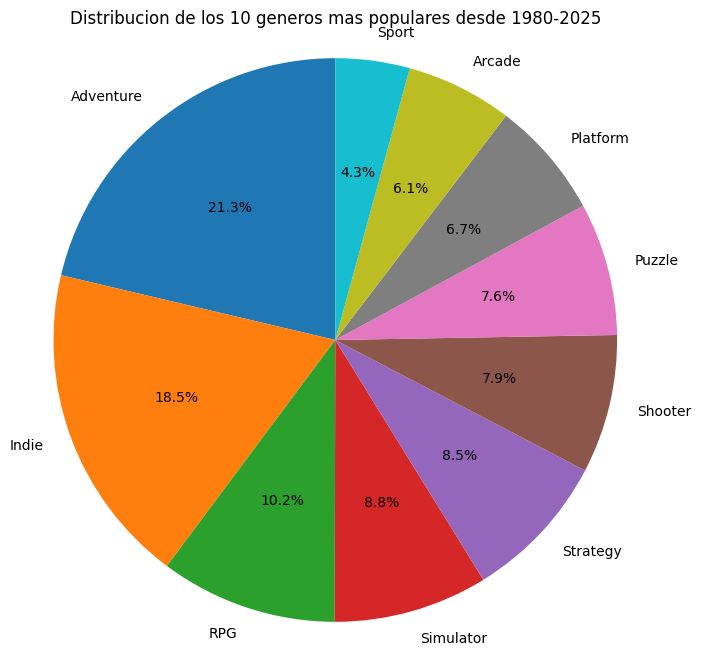

In [50]:
df_gen = df_limpio.explode("Genres_list").dropna(subset=["Genres_list"])
df_gen = df_gen[df_gen["Genres_list"] != ""]

# Contar géneros
conteo_generos = df_gen["Genres_list"].value_counts().head(10)

# Gráfico de pastel
plt.figure(figsize=(8, 8))
plt.pie(
    conteo_generos,
    labels=conteo_generos.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Distribucion de los 10 generos mas populares desde 1980-2025")
plt.axis("equal")   # Hace que el pastel sea circular
plt.show()

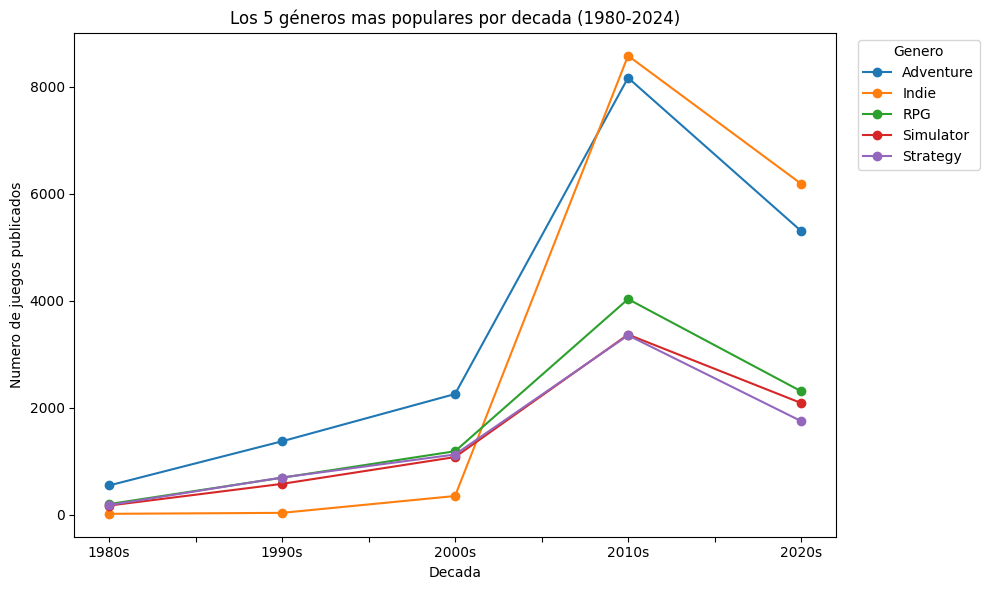

In [52]:
df_gen = df_limpio.explode("Genres_list").dropna(subset=["Genres_list", "Year"])
df_gen = df_gen[df_gen["Genres_list"] != ""]

top5_generos = df_gen["Genres_list"].value_counts().head(5).index.tolist()
tendencia = (
    df_gen[df_gen["Genres_list"].isin(top5_generos)]
    .groupby(["Decada", "Genres_list"])
    .size()
    .unstack(fill_value=0)
)
orden_decadas = [d for d in ["1980s", "1990s", "2000s", "2010s", "2020s"] if d in tendencia.index]
tendencia = tendencia.loc[orden_decadas]

tendencia.plot(kind="line", marker="o", figsize=(10, 6))
plt.title("Los 5 géneros mas populares por decada (1980-2024)")
plt.xlabel("Decada")
plt.ylabel("Numero de juegos publicados")
plt.legend(title="Genero", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()
